<a href="https://colab.research.google.com/github/piotrpowerpalka/Calculate-equilibrium/blob/master/FLAME_GPU_2_python_MARS_terraforming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Surface energy balance model for Mars based on representing the surface of Mars with a Goldberg polyhedral of 4002 cells

The approach using discretization of space with Goldberg polygons made it possible not only to obtain homogeneous spatial resolution but also the absence of a singularity at the poles in the model. In addition to the radiation terms, the surface energy balance includes CO2 condensation and evaporation, the diffusive exchange of heat between cells, heat exchange with the subsurface, and a representation of the large-scale transport of heat from the equator to pole. We validate the model by comparing model results to the Viking lander temperature and pressure data. The model results are within 10% in both temperature and pressure compared to both Viking 1 and Viking 2 landers. We also compare to current Mars GCMs. Our baseline model has a total exchangeable CO2 mass equivalent to 700 Pa and a mean annual surface temperature of 215.9 K. We use the baseline model to investigate the effects of changes in obliquity on climate. With all other model parameters held constant we find that as the obliquity increases above ~30◦ the mean annual vapor density of ground ice at the poles becomes greater than at the equator implying a net transfer of water from pole to equator. We also find there is 95% consistency with the MCD model in CO2 ice formation. The Mars polyhedral model has high spatial resolution but is still computationally efficient and can be used to simulate a variety of processes on Mars, at present or in past and future epochs.

# Installing FLAME GPU 2

The python library can be installed through pip. This installs a binary release of the FLAME GPU 2 library. Run the cell below to install the FLAME GPU 2 library.

In [21]:
import importlib.util
if importlib.util.find_spec('pyflamegpu') is None:
    import sys
    !{sys.executable} -m pip install --extra-index-url https://whl.flamegpu.com/whl/cuda120/ pyflamegpu==2.0.0rc4 # type: ignore

# Import pyflamegpu and some other libraries we will use in the tutorial
import pyflamegpu
import sys, random, math
import matplotlib.pyplot as plt


With the library installed, we need to configure the CUDA_PATH environment variable so the library can find the CUDA installation.

In [22]:
%env CUDA_PATH=/usr/local/cuda

env: CUDA_PATH=/usr/local/cuda



# The Surface Energy Balance Model
## Model Description


## The FLAME GPU 2 implementation



In [23]:
#!/usr/bin/env python3
from __future__ import annotations

import csv
import math
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional

NUM_HEXES = 4002
MARTIAN_YEAR = 668


@dataclass
class ModelConfig:
    project_dir: str = "."
    data_dir: str = "data"
    grid_csv: str = "data/fixed/out_grid_4002_0h_0_sollon.csv"
    output_dir: str = "outputs"
    sols_to_run: int = MARTIAN_YEAR * 10
    log_every: int = 10

    hadleyModel: int = 0
    deepGroundModel: int = 0

    south_dsg: float = 0.0
    north_dsg: float = 0.0
    total_sg: float = 0.18
    solar_const_modifier: float = 1.0
    k_reg: float = 1.0
    deepSoil: float = 3.47
    initDeepGrdTemp: float = 212.0
    kreg_mod: float = 1.0
    kreg_lat: float = 60.0
    ndsg_lat: float = 60.0
    sdsg_lat: float = -55.0
    spCO2defreze: float = 10e-6
    GHG_A: float = 0.004
    GHG_B: float = 0.4551
    totalCO2: float = 0.007
    tauDust: float = 0.0
    albedoGlobal: float = 0.2
    albedoIce: float = 0.5
    sigma: float = 5.670374419e-8
    ga: float = 3.72076
    S0: float = 589.0
    ecc: float = 0.09341233
    obliquity_deg: float = 24.936
    cCO2: float = 783.0
    cSoil: float = 980.0
    soilDepth: float = 2.0
    soilDensity: float = 1600.0
    emissivity: float = 0.9
    delta_t: float = 88775.0
    Kcoeff: float = 10000.0
    initFrozen: float = 0.0
    hadleyParam: float = 1e-9
    scaleHeight: float = 11600.0
    constrTemp: float = 50.0
    CO2freezingCoeff: float = 5.5e-6
    Gamma_HT: float = -0.004751 # 3.72076 / 783.0
    albedoFile: bool = False
    sunGlass_Ice: bool = False
    sun_glass_param: int = 1
    sun_glass_mode: int = 1
    variableTauDust: bool = False

    def resolve_paths(self) -> None:
        root = Path(self.project_dir).resolve()
        if not os.path.isabs(self.data_dir):
            self.data_dir = str((root / self.data_dir).resolve())
        if not os.path.isabs(self.grid_csv):
            self.grid_csv = str((root / self.grid_csv).resolve())
        if not os.path.isabs(self.output_dir):
            self.output_dir = str((root / self.output_dir).resolve())


class RuntimeData:
    def __init__(self) -> None:
        self.config: Optional[ModelConfig] = None
        self.grid: List[Dict[str, object]] = []
        self.hadley_alison: List[float] = []
        self.calib_temp_avg: List[float] = []
        self.calib_press_avg_bar: List[float] = []
        self.summary: List[Dict[str, float]] = []
        self.loaded: bool = False


RUNTIME = RuntimeData()


In [24]:


def sin_deg(deg: float) -> float:
    return math.sin(math.radians(deg))


def load_scalar_column_csv(path: str, delimiter: str, has_header: bool = True) -> List[float]:
    values: List[float] = []
    with open(path, newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f, delimiter=delimiter)
        if has_header:
            next(reader, None)
        for row in reader:
            if row and row[0].strip():
                values.append(float(row[0].strip()))
    return values


def load_calibration(path: str) -> tuple[List[float], List[float]]:
    temps = [float("nan")] * MARTIAN_YEAR
    press = [float("nan")] * MARTIAN_YEAR
    with open(path, newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f, delimiter=';')
        next(reader, None)
        idx = 0
        for row in reader:
            if len(row) >= 5 and idx < MARTIAN_YEAR:
                temps[idx] = float(row[1])
                press[idx] = float(row[4]) / 1.0e5
                idx += 1
    return temps, press


def load_hudley_al(path: str) -> List[float]:
    table = [0.0] * (NUM_HEXES * MARTIAN_YEAR)
    with open(path, newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f, delimiter=';')
        for row in reader:
            if len(row) < 3:
                continue
            hex_id = int(row[0]) - 1
            sol = int(row[1])
            val = float(row[2])
            if 0 <= hex_id < NUM_HEXES and 0 <= sol < MARTIAN_YEAR:
                table[hex_id * MARTIAN_YEAR + sol] = val
    return table


def compute_dust_sunglasses(row: Dict[str, object], cfg: ModelConfig) -> float:
    south_ids = {
        1751, 1752, 1753, 1769, 1770, 1771, 1772, 1787, 1788, 1789, 1790, 1791,
        1835, 1844, 1845, 1854, 1855, 1865, 1866,
    }
    north_ids = {
        2841, 2849, 49, 2858, 59, 2850, 2859, 58, 2869, 69, 2860, 2870,
        68, 2871, 80, 2881, 79, 2882, 2883,
    }
    dust = 0.0
    lat = float(row["latitude"])
    cell_id = int(row["id_cell"])
    if cfg.sun_glass_param == 0:
        if cell_id in south_ids:
            dust = cfg.south_dsg
        if cell_id in north_ids:
            dust = cfg.north_dsg
    elif cfg.sun_glass_param == 1:
        if lat < cfg.sdsg_lat:
            if cfg.sun_glass_mode == 0:
                dust = cfg.south_dsg
            else:
                dust = sin_deg(90.0 * (abs(lat) + cfg.sdsg_lat) / (90.0 + cfg.sdsg_lat)) * cfg.south_dsg
        if lat > cfg.ndsg_lat:
            if cfg.sun_glass_mode == 0:
                dust = cfg.north_dsg
            else:
                dust = sin_deg(90.0 * (abs(lat) - cfg.ndsg_lat) / (90.0 - cfg.ndsg_lat)) * cfg.north_dsg
    elif cfg.sun_glass_param == 2:
        if lat > 0.0:
            dust = cfg.north_dsg
        elif lat < 0.0:
            dust = cfg.south_dsg
    return dust


def load_grid_csv(path: str, albedo: List[float], hadley_coeff: List[float]) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    with open(path, newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f, delimiter=';')
        for raw in reader:
            neigh = [int(raw[f"n{i}"]) for i in range(1, 7)]
            azim = [int(raw[f"a{i}"]) for i in range(1, 7)]
            pairs = sorted((a, n) for a, n in zip(azim, neigh) if n > 0)
            neigh_sorted = [0] * 6
            azim_sorted = [0] * 6
            for idx, (a, n) in enumerate(pairs[:6]):
                azim_sorted[idx] = a
                neigh_sorted[idx] = n
            cell_id = int(raw["id"])
            grid_index = cell_id - 1
            rows.append({
                "id_cell": cell_id,
                "grid_index": grid_index,
                "x": float(raw["x"]),
                "y": float(raw["y"]),
                "z": float(raw["z"]),
                "latitude": float(raw["lattitude"]),
                "longitude": float(raw["longitude"]),
                "spec": int(raw["spec"]),
                "neigh": neigh_sorted,
                "azim": azim_sorted,
                "neigh_count": len(pairs),
                "atm_press": float(raw["atmpress"]),
                "temp": float(raw["temp"]),
                "zonal_wind": float(raw["zonalwind"]),
                "merid_wind": float(raw["meridwind"]),
                "height": float(raw["ex2"]),
                "albedo": albedo[grid_index] if 0 <= grid_index < len(albedo) else 0.2,
                "hadley_ht": hadley_coeff[grid_index] if 0 <= grid_index < len(hadley_coeff) else 0.0,
                "dust_sunglasses": 0.0,
            })
    return rows


def load_runtime_data(config: ModelConfig) -> None:
    config.resolve_paths()
    if RUNTIME.loaded and RUNTIME.config == config:
        return

    RUNTIME.config = config
    albedo = load_scalar_column_csv(os.path.join(config.data_dir, "heksy_albedo.csv"), ';', True)
    hadley_csv = "hudley_new.csv" if config.hadleyModel == 2 else "hadley_heat_transport.csv"
    hadley_coeff = load_scalar_column_csv(os.path.join(config.data_dir, hadley_csv), ',', True)
    if len(hadley_coeff) < NUM_HEXES:
        hadley_coeff.extend([0.0] * (NUM_HEXES - len(hadley_coeff)))

    RUNTIME.grid = load_grid_csv(config.grid_csv, albedo, hadley_coeff)
    for row in RUNTIME.grid:
        row["dust_sunglasses"] = compute_dust_sunglasses(row, config)

    hudley_al_path = os.path.join(config.data_dir, "hudley_al.csv")
    RUNTIME.hadley_alison = load_hudley_al(hudley_al_path) if os.path.exists(hudley_al_path) else []

    calib_path = os.path.join(config.data_dir, "calib_data.csv")
    if os.path.exists(calib_path):
        RUNTIME.calib_temp_avg, RUNTIME.calib_press_avg_bar = load_calibration(calib_path)
    else:
        RUNTIME.calib_temp_avg, RUNTIME.calib_press_avg_bar = [], []

    RUNTIME.summary = []
    RUNTIME.loaded = True



In [25]:

OUTPUT_TPS_RTC = r'''
FLAMEGPU_AGENT_FUNCTION(output_tps_message, flamegpu::MessageNone, flamegpu::MessageArray) {
    const unsigned int index = static_cast<unsigned int>(FLAMEGPU->getVariable<int>("grid_index"));
    const float tps = FLAMEGPU->getVariable<float>("Tps");
    FLAMEGPU->message_out.setIndex(index);
    FLAMEGPU->message_out.setVariable<float>("tps", tps);
    return flamegpu::ALIVE;
}
'''

FINITE_ELEMENT_RTC = r'''
FLAMEGPU_AGENT_FUNCTION(finite_element_diffusion, flamegpu::MessageArray, flamegpu::MessageNone) {
    const int neigh_count = FLAMEGPU->getVariable<int>("neigh_count");
    const int spec = FLAMEGPU->getVariable<int>("spec");
    const float Tps = FLAMEGPU->getVariable<float>("Tps");
    float neigh_sum = 0.0f;
    for (int i = 0; i < neigh_count; ++i) {
        const int neigh_id = FLAMEGPU->getVariable<int, 6>("neigh", i);
        if (neigh_id > 0) {
            const auto msg = FLAMEGPU->message_in.at(static_cast<unsigned int>(neigh_id - 1));
            neigh_sum += msg.getVariable<float>("tps");
        }
    }
    const float param = (1 - spec) * (4.0f / 6.0f) + spec * (4.0f / 5.0f);
    const float K_ = FLAMEGPU->environment.getProperty<float>("K_");
    const float eddy = K_ * (param * neigh_sum - 4.0f * Tps);
    FLAMEGPU->setVariable<float>("eddy_Ts", eddy);
    return flamegpu::ALIVE;
}
'''

BALANCE_UPDATE_RTC = r'''
#define MARS_PI_F 3.14159265358979323846f
FLAMEGPU_HOST_DEVICE_FUNCTION float mars_deg_to_rad(const float deg) { return deg * MARS_PI_F / 180.0f; }
FLAMEGPU_HOST_DEVICE_FUNCTION float mars_sin_deg(const float deg) { return sinf(mars_deg_to_rad(deg)); }
FLAMEGPU_HOST_DEVICE_FUNCTION float mars_cos_deg(const float deg) { return cosf(mars_deg_to_rad(deg)); }
FLAMEGPU_HOST_DEVICE_FUNCTION float mars_tan_deg(const float deg) { return tanf(mars_deg_to_rad(deg)); }
FLAMEGPU_HOST_DEVICE_FUNCTION float mars_acos_deg(const float x) {
    const float clamped = x < -1.0f ? -1.0f : (x > 1.0f ? 1.0f : x);
    return acosf(clamped) * 180.0f / MARS_PI_F;
}
FLAMEGPU_AGENT_FUNCTION(balance_update, flamegpu::MessageNone, flamegpu::MessageNone) {
    const float latitude_raw = FLAMEGPU->getVariable<float>("latitude");
    float fi = latitude_raw;
    if (fi == 90.0f) fi = 89.99f; else if (fi == -90.0f) fi = -89.99f;

    const float obliquity_deg = FLAMEGPU->environment.getProperty<float>("obliquity_deg");
    const float sol_lon = static_cast<float>(FLAMEGPU->environment.getProperty<unsigned int>("sol_lon_deg"));
    const float solar_const_modifier = FLAMEGPU->environment.getProperty<float>("solar_const_modifier");
    const float S0 = FLAMEGPU->environment.getProperty<float>("S0");
    const float e = FLAMEGPU->environment.getProperty<float>("ecc");
    const float sigma = FLAMEGPU->environment.getProperty<float>("sigma");
    const float emissivity = FLAMEGPU->environment.getProperty<float>("emissivity");
    const float tauDust = FLAMEGPU->environment.getProperty<float>("tauDust");
    const unsigned int variableTauDust = FLAMEGPU->environment.getProperty<unsigned int>("variableTauDust");
    const float GHG_A = FLAMEGPU->environment.getProperty<float>("GHG_A");
    const float GHG_B = FLAMEGPU->environment.getProperty<float>("GHG_B");
    const float Pa2bar = 1.0e5f;
    const float ga = FLAMEGPU->environment.getProperty<float>("ga");
    const float cCO2 = FLAMEGPU->environment.getProperty<float>("cCO2");
    const float cSoil = FLAMEGPU->environment.getProperty<float>("cSoil");
    const float soilDepth = FLAMEGPU->environment.getProperty<float>("soilDepth");
    const float soilDensity = FLAMEGPU->environment.getProperty<float>("soilDensity");
    const float delta_t = FLAMEGPU->environment.getProperty<float>("delta_t");
    const float scaleHeight = FLAMEGPU->environment.getProperty<float>("scaleHeight");
    const float constrTemp = FLAMEGPU->environment.getProperty<float>("constrTemp");
    const float albedoGlobal = FLAMEGPU->environment.getProperty<float>("albedoGlobal");
    const float albedoIce = FLAMEGPU->environment.getProperty<float>("albedoIce");
    const unsigned int albedoFile = FLAMEGPU->environment.getProperty<unsigned int>("albedoFile");
    const unsigned int sunGlassIce = FLAMEGPU->environment.getProperty<unsigned int>("sunGlass_Ice");
    const float total_sg = FLAMEGPU->environment.getProperty<float>("total_sg");
    const float atmCO2 = FLAMEGPU->environment.getProperty<float>("atmCO2");
    const float totalCO2 = FLAMEGPU->environment.getProperty<float>("totalCO2");
    const float CO2freezingCoeff = FLAMEGPU->environment.getProperty<float>("CO2freezingCoeff");
    const float spCO2defreze = FLAMEGPU->environment.getProperty<float>("spCO2defreze");
    const float deepSoil = FLAMEGPU->environment.getProperty<float>("deepSoil");
    const float k_reg = FLAMEGPU->environment.getProperty<float>("k_reg");
    const float kreg_mod = FLAMEGPU->environment.getProperty<float>("kreg_mod");
    const float kreg_lat = FLAMEGPU->environment.getProperty<float>("kreg_lat");
    const unsigned int deepGroundModel = FLAMEGPU->environment.getProperty<unsigned int>("deepGroundModel");
    const float Gamma_HT = FLAMEGPU->environment.getProperty<float>("Gamma_HT");
    const float sdsg_lat = FLAMEGPU->environment.getProperty<float>("sdsg_lat");

    const float height = FLAMEGPU->getVariable<float>("height");
    const float dust_sunglasses = FLAMEGPU->getVariable<float>("dust_sunglasses");
    const float local_albedo = FLAMEGPU->getVariable<float>("albedo");
    float Ts = FLAMEGPU->getVariable<float>("Ts");
    const float prevTs = Ts;
    const float initial_frozen = FLAMEGPU->getVariable<float>("frozenCO2");
    float frozenCO2 = initial_frozen;
    const float eddy_Ts = FLAMEGPU->getVariable<float>("eddy_Ts");
    const float hadley_Ts = FLAMEGPU->getVariable<float>("hadley_Ts");
    float subground_Ts = FLAMEGPU->getVariable<float>("subground_Ts");

    const float kat = obliquity_deg * mars_sin_deg(sol_lon);
    const float zachSlonca = -mars_tan_deg(fi) * mars_tan_deg(kat);
    float OMEGA = 0.0f;
    if (zachSlonca >= 1.0f) OMEGA = 0.0f; else if (zachSlonca <= -1.0f) OMEGA = 180.0f; else OMEGA = mars_acos_deg(zachSlonca);

    const float orbit_term = powf(1.0f + e * mars_cos_deg(fmodf(sol_lon - 248.0f + 360.0f, 360.0f)), 2.0f) / powf(1.0f - e * e, 2.0f);
    const float solar_factor = mars_sin_deg(fi) * mars_sin_deg(obliquity_deg) * mars_sin_deg(sol_lon) * OMEGA * 2.0f * MARS_PI_F / 360.0f
        + mars_cos_deg(fi) * mars_cos_deg(kat) * mars_sin_deg(OMEGA);
    const float insol = (1.0f / MARS_PI_F) * S0 * solar_const_modifier * orbit_term * fmaxf(0.0f, solar_factor);

    bool pCO2greater = false;
    float co2_excess_factor = 1.0f;
    float pCO2 = 0.0f;
    float PsatCO2 = 0.0f;
    float Tsat = 0.0f;
    float tCO2 = 0.0f;
    float tau = 0.0f;
    float latentCO2 = 0.0f;
    float insol_en = 0.0f;
    float rad_en = 0.0f;
    float green_en = 0.0f;
    float ground_delta_En = 0.0f;
    float energy = 0.0f;
    float tauDustN = tauDust;

    for (int it = 0; it < 10; ++it) {
        pCO2 = atmCO2 * expf(-height / scaleHeight);
        if (pCO2 < 1.0e-8f) pCO2 = 1.0e-8f;
        PsatCO2 = 1.2264e7f * expf(-3167.8f / Ts);
        Tsat = -3167.8f / logf(pCO2 / 1.2264e7f);
        if (variableTauDust) tauDustN = tauDust * pCO2 / fmaxf(atmCO2, 1.0e-8f);
        tCO2 = GHG_A * powf((pCO2 * Pa2bar) / ga, GHG_B);
        tau = tCO2 + tauDustN;

        latentCO2 = 0.0f;
        if (albedoFile) {
            if (!sunGlassIce) {
                insol_en = (1.0f - dust_sunglasses) * ((frozenCO2 > 1.0e-8f) ? (1.0f - (albedoIce - albedoGlobal + local_albedo)) : (1.0f - local_albedo)) * insol;
            } else {
                insol_en = (1.0f - ((frozenCO2 > 1.0e-8f) ? dust_sunglasses : 0.0f)) * ((frozenCO2 > 1.0e-8f) ? (1.0f - (albedoIce - albedoGlobal + local_albedo)) : (1.0f - local_albedo)) * insol;
            }
        } else {
            if (!sunGlassIce) {
                insol_en = (1.0f - dust_sunglasses) * ((frozenCO2 > 1.0e-8f) ? (1.0f - albedoIce) : (1.0f - albedoGlobal)) * insol;
            } else {
                insol_en = (1.0f - ((frozenCO2 > 1.0e-8f) ? dust_sunglasses : 0.0f)) * ((frozenCO2 > 1.0e-8f) ? (1.0f - albedoIce) : (1.0f - albedoGlobal)) * insol;
            }
        }
        insol_en *= (1.0f - total_sg);
        rad_en = emissivity * sigma * powf(Ts, 4.0f);
        green_en = sigma * powf(Ts, 4.0f) * (((7.0f / 8.0f + 3.0f / 2.0f * tau) * (1.0f - expf(-2.0f * tau))) - 3.0f / 4.0f * tau) / (1.0f + 3.0f / 4.0f * tau);

        float co2_excess = 0.0f;
        if (pCO2 > PsatCO2) {
            pCO2greater = true;
            if (latitude_raw < sdsg_lat) co2_excess = co2_excess_factor * totalCO2 * spCO2defreze * (Tsat - Ts);
            else co2_excess = co2_excess_factor * totalCO2 * CO2freezingCoeff * (Tsat - Ts);
            if (co2_excess > atmCO2 / 4002.0f) co2_excess = atmCO2 / 4002.0f;
            frozenCO2 += co2_excess;
            latentCO2 += co2_excess * 613000.0f * 4002.0f;
        } else if (pCO2 < PsatCO2) {
            pCO2greater = false;
            if (latitude_raw < sdsg_lat) co2_excess = co2_excess_factor * totalCO2 * spCO2defreze * (Ts - Tsat);
            else co2_excess = co2_excess_factor * totalCO2 * CO2freezingCoeff * (Ts - Tsat);
            if (co2_excess > frozenCO2) co2_excess = frozenCO2;
            frozenCO2 -= co2_excess;
            latentCO2 -= co2_excess * 613000.0f * 4002.0f;
        }

        if (latitude_raw <= kreg_lat && latitude_raw >= -kreg_lat) ground_delta_En = k_reg * (Ts - subground_Ts) / deepSoil;
        else ground_delta_En = k_reg * kreg_mod * (Ts - subground_Ts) / deepSoil;
        if (!deepGroundModel) ground_delta_En = 0.0f;

        energy = insol_en - rad_en + green_en + eddy_Ts + hadley_Ts + latentCO2 - ground_delta_En;
        float tmpTs = Ts + energy * delta_t / (cCO2 * pCO2 + cSoil * soilDepth * soilDensity);
        if (tmpTs < constrTemp) tmpTs = constrTemp;
        const float tmpPsatCO2 = 1.2264e7f * expf(-3167.8f / tmpTs);
        const float tmpPCO2 = (atmCO2 + ((pCO2greater ? 1.0f : -1.0f) * (frozenCO2 - initial_frozen))) * expf(-height / scaleHeight);
        if ((tmpPCO2 > tmpPsatCO2 && pCO2greater) || (tmpPCO2 < tmpPsatCO2 && !pCO2greater)) break;
        co2_excess_factor *= 0.5f;
    }

    Ts = Ts + energy * delta_t / (cCO2 * pCO2 + cSoil * soilDepth * soilDensity);
    if (Ts < constrTemp) Ts = constrTemp;
    subground_Ts = subground_Ts + delta_t * ground_delta_En / (cSoil * soilDensity * deepSoil);
    const float Tps = Ts - Gamma_HT * height;

    FLAMEGPU->setVariable<float>("insol", insol);
    FLAMEGPU->setVariable<float>("energy", energy);
    FLAMEGPU->setVariable<float>("heat_flux", FLAMEGPU->getVariable<float>("heat_flux") - energy);
    FLAMEGPU->setVariable<float>("prevTs", prevTs);
    FLAMEGPU->setVariable<float>("Ts", Ts);
    FLAMEGPU->setVariable<float>("Tps", Tps);
    FLAMEGPU->setVariable<float>("pCO2", pCO2);
    FLAMEGPU->setVariable<float>("PsatCO2", PsatCO2);
    FLAMEGPU->setVariable<float>("Tsat", Tsat);
    FLAMEGPU->setVariable<float>("tCO2", tCO2);
    FLAMEGPU->setVariable<float>("tau", tau);
    FLAMEGPU->setVariable<float>("latentCO2", latentCO2);
    FLAMEGPU->setVariable<float>("insol_en", insol_en);
    FLAMEGPU->setVariable<float>("rad_en", rad_en);
    FLAMEGPU->setVariable<float>("green_en", green_en);
    FLAMEGPU->setVariable<float>("ground_delta_En", ground_delta_En);
    FLAMEGPU->setVariable<float>("frozenCO2", frozenCO2);
    FLAMEGPU->setVariable<float>("subground_Ts", subground_Ts);
    return flamegpu::ALIVE;
}
'''




[sol 0] mean_T=185.231 mean_p=0.007545 frozen=0.000005
[sol 10] mean_T=192.901 mean_p=0.007534 frozen=0.000011
[sol 20] mean_T=197.673 mean_p=0.007530 frozen=0.000014
[sol 30] mean_T=200.397 mean_p=0.007530 frozen=0.000014
[sol 40] mean_T=201.798 mean_p=0.007530 frozen=0.000013
[sol 50] mean_T=202.376 mean_p=0.007530 frozen=0.000015
[sol 60] mean_T=202.456 mean_p=0.007523 frozen=0.000021
[sol 70] mean_T=202.236 mean_p=0.007511 frozen=0.000033
[sol 80] mean_T=201.841 mean_p=0.007493 frozen=0.000050
[sol 90] mean_T=201.366 mean_p=0.007464 frozen=0.000078
[sol 100] mean_T=200.865 mean_p=0.007422 frozen=0.000118
[sol 110] mean_T=200.385 mean_p=0.007366 frozen=0.000171
[sol 120] mean_T=199.958 mean_p=0.007299 frozen=0.000235
[sol 130] mean_T=199.591 mean_p=0.007216 frozen=0.000312
[sol 140] mean_T=199.306 mean_p=0.007117 frozen=0.000406
[sol 150] mean_T=199.104 mean_p=0.007010 frozen=0.000505
[sol 160] mean_T=198.996 mean_p=0.006896 frozen=0.000613
[sol 170] mean_T=198.980 mean_p=0.006780 f

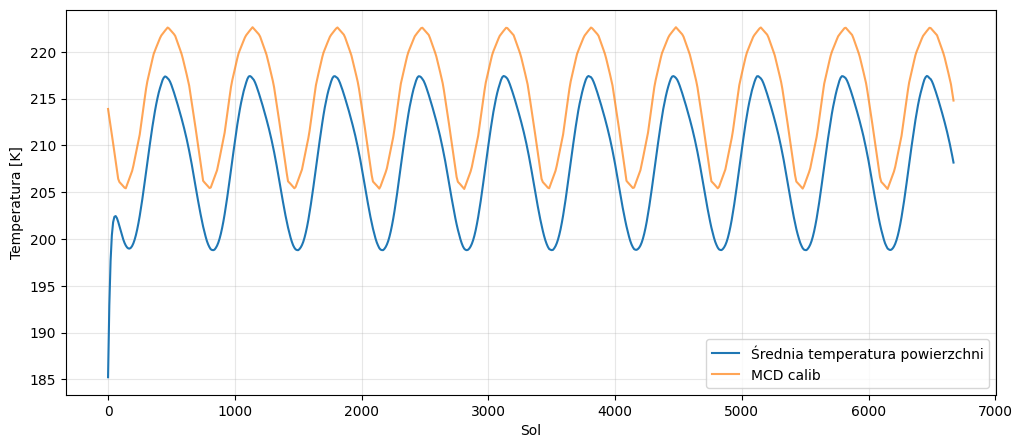

{'summary_path': '/content/outputs/summary.csv', 'final_state_path': '/content/outputs/final_state.csv', 'output_dir': '/content/outputs'}


In [26]:

class InitialiseCells(pyflamegpu.HostFunction):
    def run(self, FLAMEGPU):
        cfg = RUNTIME.config
        assert cfg is not None
        os.makedirs(cfg.output_dir, exist_ok=True)
        FLAMEGPU.environment.setPropertyFloat("totalCO2", cfg.totalCO2)
        FLAMEGPU.environment.setPropertyFloat("atmCO2", cfg.totalCO2)
        FLAMEGPU.environment.setPropertyFloat("sumFrozen", 0.0)
        FLAMEGPU.environment.setPropertyUInt("sol_year", 0)
        FLAMEGPU.environment.setPropertyUInt("year", 0)
        FLAMEGPU.environment.setPropertyUInt("sol_lon_deg", 0)
        FLAMEGPU.environment.setPropertyFloat("mean_greenhouse_temp", 0.0)
        FLAMEGPU.environment.setPropertyFloat("mean_equatorial_temp", 0.0)
        FLAMEGPU.environment.setPropertyFloat("mean_npole_temp", 0.0)
        FLAMEGPU.environment.setPropertyFloat("mean_spole_temp", 0.0)

        cells = FLAMEGPU.agent("cell")
        for row in RUNTIME.grid:
            a = cells.newAgent()
            a.setVariableInt("id_cell", int(row["id_cell"]))
            a.setVariableInt("grid_index", int(row["grid_index"]))
            a.setVariableFloat("x", float(row["x"]))
            a.setVariableFloat("y", float(row["y"]))
            a.setVariableFloat("z", float(row["z"]))
            a.setVariableFloat("latitude", float(row["latitude"]))
            a.setVariableFloat("longitude", float(row["longitude"]))
            a.setVariableInt("spec", int(row["spec"]))
            a.setVariableArrayInt("neigh", list(row["neigh"]))
            a.setVariableArrayInt("azim", list(row["azim"]))
            a.setVariableInt("neigh_count", int(row["neigh_count"]))
            a.setVariableFloat("atm_press", float(row["atm_press"]))
            a.setVariableFloat("temp", float(row["temp"]))
            a.setVariableFloat("zonal_wind", float(row["zonal_wind"]))
            a.setVariableFloat("merid_wind", float(row["merid_wind"]))
            a.setVariableFloat("height", float(row["height"]))
            a.setVariableFloat("albedo", float(row["albedo"]))
            a.setVariableFloat("hadley_ht", float(row["hadley_ht"]))
            a.setVariableFloat("dust_sunglasses", float(row["dust_sunglasses"]))
            Ts = float(row["temp"])
            frozen = cfg.totalCO2 * cfg.initFrozen / float(NUM_HEXES)
            pCO2 = cfg.totalCO2 * math.exp(-float(row["height"]) / cfg.scaleHeight)
            Tps = Ts - cfg.Gamma_HT * float(row["height"])
            a.setVariableFloat("energy", 0.0)
            a.setVariableFloat("heat_flux", 0.0)
            a.setVariableFloat("prevTs", Ts)
            a.setVariableFloat("Ts", Ts)
            a.setVariableFloat("Tps", Tps)
            a.setVariableFloat("frozenCO2", frozen)
            a.setVariableFloat("pCO2", pCO2)
            a.setVariableFloat("PsatCO2", 1.2264e7 * math.exp(-3167.8 / Ts))
            a.setVariableFloat("Tsat", -3167.8 / math.log(max(pCO2, 1.0e-8) / 1.2264e7))
            a.setVariableFloat("tCO2", 0.0)
            a.setVariableFloat("tau", 0.0)
            a.setVariableFloat("eddy_Ts", 0.0)
            a.setVariableFloat("hadley_Ts", 0.0)
            a.setVariableFloat("ground_delta_En", 0.0)
            a.setVariableFloat("subground_Ts", cfg.initDeepGrdTemp)
            a.setVariableFloat("insol", 0.0)
            a.setVariableFloat("insol_en", 0.0)
            a.setVariableFloat("rad_en", 0.0)
            a.setVariableFloat("green_en", 0.0)
            a.setVariableFloat("latentCO2", 0.0)


class UpdateGlobalStateAndHadley(pyflamegpu.HostFunction):
    def run(self, FLAMEGPU):
        cfg = RUNTIME.config
        assert cfg is not None
        cells_api = FLAMEGPU.agent("cell")
        cells = cells_api.getPopulationData()
        step = FLAMEGPU.getStepCounter()
        sol_year = step % MARTIAN_YEAR
        year = step // MARTIAN_YEAR
        sol_lon_deg = int((float(sol_year) / float(MARTIAN_YEAR)) * 360.0)

        sum_frozen = 0.0
        sum_ts = 0.0
        sum_eq = 0.0
        sum_n = 0.0
        sum_s = 0.0
        count = cells_api.count()
        count_eq = 0
        count_n = 0
        count_s = 0
        hadley_n = 0.0
        hadley_s = 0.0

        for c in cells:
            Ts = c.getVariableFloat("Ts")
            lat = c.getVariableFloat("latitude")
            frozen = c.getVariableFloat("frozenCO2")
            coeff = c.getVariableFloat("hadley_ht")
            sum_frozen += frozen
            sum_ts += Ts
            if -2.0 <= lat <= 2.0:
                sum_eq += Ts
                count_eq += 1
            if lat >= 90.0:
                sum_n += Ts
                count_n += 1
            if lat <= -90.0:
                sum_s += Ts
                count_s += 1
            if cfg.hadleyModel in (0, 2) and coeff > 0.0:
                seed = coeff * Ts * cfg.hadleyParam
                if lat > 0.0:
                    hadley_n += seed
                elif lat < 0.0:
                    hadley_s += seed
                else:
                    hadley_n += 0.5 * seed
                    hadley_s += 0.5 * seed

        mean_ts = (sum_ts / count) if count else 0.0
        mean_eq = (sum_eq / count_eq) if count_eq else mean_ts
        mean_n = (sum_n / count_n) if count_n else mean_ts
        mean_s = (sum_s / count_s) if count_s else mean_ts
        atmCO2 = cfg.totalCO2 - sum_frozen

        FLAMEGPU.environment.setPropertyUInt("sol_year", sol_year)
        FLAMEGPU.environment.setPropertyUInt("year", year)
        FLAMEGPU.environment.setPropertyUInt("sol_lon_deg", sol_lon_deg)
        FLAMEGPU.environment.setPropertyFloat("sumFrozen", float(sum_frozen))
        FLAMEGPU.environment.setPropertyFloat("atmCO2", float(atmCO2))
        FLAMEGPU.environment.setPropertyFloat("mean_greenhouse_temp", float(mean_ts))
        FLAMEGPU.environment.setPropertyFloat("mean_equatorial_temp", float(mean_eq))
        FLAMEGPU.environment.setPropertyFloat("mean_npole_temp", float(mean_n))
        FLAMEGPU.environment.setPropertyFloat("mean_spole_temp", float(mean_s))

        spread_factor = math.sqrt(max(mean_ts, 0.0)) * ((mean_eq - (mean_n + mean_s) * 0.5) ** 2)
        for c in cells:
            cell_id = c.getVariableInt("id_cell")
            lat = c.getVariableFloat("latitude")
            coeff = c.getVariableFloat("hadley_ht")
            hadley_ts = 0.0
            if cfg.hadleyModel == 1 and RUNTIME.hadley_alison:
                idx = (cell_id - 1) * MARTIAN_YEAR + sol_year
                if 0 <= idx < len(RUNTIME.hadley_alison):
                    hadley_ts = RUNTIME.hadley_alison[idx]
            elif cfg.hadleyModel in (0, 2):
                if coeff < 0.0 and lat > 0.0:
                    hadley_ts = -coeff * hadley_n
                elif coeff < 0.0 and lat < 0.0:
                    hadley_ts = -coeff * hadley_s
                hadley_ts *= spread_factor
            c.setVariableFloat("hadley_Ts", float(hadley_ts))
        cells.syncChanges()


class CaptureSummary(pyflamegpu.HostFunction):
    def run(self, FLAMEGPU):
        cfg = RUNTIME.config
        assert cfg is not None
        step = FLAMEGPU.getStepCounter()
        if cfg.log_every <= 0 or (step % cfg.log_every) != 0:
            return
        cells_api = FLAMEGPU.agent("cell")
        cells = cells_api.getPopulationData()
        count = cells_api.count()
        sum_ts = 0.0
        sum_p = 0.0
        sum_frozen = 0.0
        temp333 = float("nan")
        press333 = float("nan")
        temp3090 = float("nan")
        press3090 = float("nan")
        for c in cells:
            cell_id = c.getVariableInt("id_cell")
            Ts = c.getVariableFloat("Ts")
            p = c.getVariableFloat("pCO2")
            frozen = c.getVariableFloat("frozenCO2")
            sum_ts += Ts
            sum_p += p
            sum_frozen += frozen
            if cell_id == 333:
                temp333 = Ts
                press333 = p
            elif cell_id == 3090:
                temp3090 = Ts
                press3090 = p
        sol_year = step % MARTIAN_YEAR
        row = {
            "sol": float(step),
            "year": float(step // MARTIAN_YEAR),
            "sol_year": float(sol_year),
            "mean_temp": float(sum_ts / count) if count else 0.0,
            "mean_pressure": float(sum_p / count) if count else 0.0,
            "sum_frozen": float(sum_frozen),
            "temp_333": temp333,
            "pressure_333": press333,
            "temp_3090": temp3090,
            "pressure_3090": press3090,
            "mcd_temp": RUNTIME.calib_temp_avg[sol_year] if sol_year < len(RUNTIME.calib_temp_avg) else float("nan"),
            "mcd_pressure_bar": RUNTIME.calib_press_avg_bar[sol_year] if sol_year < len(RUNTIME.calib_press_avg_bar) else float("nan"),
        }
        RUNTIME.summary.append(row)
        print(f"[sol {int(row['sol'])}] mean_T={row['mean_temp']:.3f} mean_p={row['mean_pressure']:.6f} frozen={row['sum_frozen']:.6f}")


class WriteOutputs(pyflamegpu.HostFunction):
    def run(self, FLAMEGPU):
        cfg = RUNTIME.config
        assert cfg is not None
        os.makedirs(cfg.output_dir, exist_ok=True)
        with open(os.path.join(cfg.output_dir, "summary.csv"), "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["sol", "year", "sol_year", "mean_temp", "mean_pressure", "sum_frozen", "temp_333", "pressure_333", "temp_3090", "pressure_3090", "mcd_temp", "mcd_pressure_bar"])
            for row in RUNTIME.summary:
                writer.writerow([int(row["sol"]), int(row["year"]), int(row["sol_year"]), row["mean_temp"], row["mean_pressure"], row["sum_frozen"], row["temp_333"], row["pressure_333"], row["temp_3090"], row["pressure_3090"], row["mcd_temp"], row["mcd_pressure_bar"]])
        cells = FLAMEGPU.agent("cell").getPopulationData()
        with open(os.path.join(cfg.output_dir, "final_state.csv"), "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["id_cell", "latitude", "longitude", "height", "Ts", "Tps", "pCO2", "frozenCO2", "energy", "insol", "eddy_Ts", "hadley_Ts", "ground_delta_En", "subground_Ts"])
            for c in cells:
                writer.writerow([c.getVariableInt("id_cell"), c.getVariableFloat("latitude"), c.getVariableFloat("longitude"), c.getVariableFloat("height"), c.getVariableFloat("Ts"), c.getVariableFloat("Tps"), c.getVariableFloat("pCO2"), c.getVariableFloat("frozenCO2"), c.getVariableFloat("energy"), c.getVariableFloat("insol"), c.getVariableFloat("eddy_Ts"), c.getVariableFloat("hadley_Ts"), c.getVariableFloat("ground_delta_En"), c.getVariableFloat("subground_Ts")])


def build_model(config: Optional[ModelConfig] = None):
    cfg = config or ModelConfig(project_dir=str(Path(__file__).resolve().parent))
    load_runtime_data(cfg)
    model = pyflamegpu.ModelDescription("Mars First Tree - FLAME GPU 2 Python Port")

    tps_msg = model.newMessageArray("tps_message")
    tps_msg.setLength(NUM_HEXES)
    tps_msg.newVariableFloat("tps")

    cell = model.newAgent("cell")
    cell.newVariableInt("id_cell")
    cell.newVariableInt("grid_index")
    cell.newVariableFloat("x")
    cell.newVariableFloat("y")
    cell.newVariableFloat("z")
    cell.newVariableFloat("latitude")
    cell.newVariableFloat("longitude")
    cell.newVariableInt("spec")
    cell.newVariableArrayInt("neigh", 6)
    cell.newVariableArrayInt("azim", 6)
    cell.newVariableInt("neigh_count", 0)
    cell.newVariableFloat("atm_press", 0.0)
    cell.newVariableFloat("temp", 140.0)
    cell.newVariableFloat("zonal_wind", 0.0)
    cell.newVariableFloat("merid_wind", 0.0)
    cell.newVariableFloat("height", 0.0)
    cell.newVariableFloat("albedo", 0.2)
    cell.newVariableFloat("hadley_ht", 0.0)
    cell.newVariableFloat("dust_sunglasses", 0.0)
    for v in ["energy", "heat_flux", "prevTs", "Ts", "Tps", "frozenCO2", "pCO2", "PsatCO2", "Tsat", "tCO2", "tau", "eddy_Ts", "hadley_Ts", "ground_delta_En", "subground_Ts", "insol", "insol_en", "rad_en", "green_en", "latentCO2"]:
        cell.newVariableFloat(v, 0.0)

    out_fn = cell.newRTCFunction("output_tps_message", OUTPUT_TPS_RTC)
    out_fn.setMessageOutput("tps_message")
    diff_fn = cell.newRTCFunction("finite_element_diffusion", FINITE_ELEMENT_RTC)
    diff_fn.setMessageInput("tps_message")
    balance_fn = cell.newRTCFunction("balance_update", BALANCE_UPDATE_RTC)

    env = model.Environment()
    env.newPropertyUInt("num_hexes", NUM_HEXES)
    env.newPropertyFloat("K_", cfg.Kcoeff / 1000.0)
    env.newPropertyFloat("solar_const_modifier", cfg.solar_const_modifier)
    env.newPropertyFloat("S0", cfg.S0)
    env.newPropertyFloat("ecc", cfg.ecc)
    env.newPropertyFloat("sigma", cfg.sigma)
    env.newPropertyFloat("emissivity", cfg.emissivity)
    env.newPropertyFloat("tauDust", cfg.tauDust)
    env.newPropertyUInt("variableTauDust", int(cfg.variableTauDust))
    env.newPropertyFloat("GHG_A", cfg.GHG_A)
    env.newPropertyFloat("GHG_B", cfg.GHG_B)
    env.newPropertyFloat("ga", cfg.ga)
    env.newPropertyFloat("cCO2", cfg.cCO2)
    env.newPropertyFloat("cSoil", cfg.cSoil)
    env.newPropertyFloat("soilDepth", cfg.soilDepth)
    env.newPropertyFloat("soilDensity", cfg.soilDensity)
    env.newPropertyFloat("delta_t", cfg.delta_t)
    env.newPropertyFloat("scaleHeight", cfg.scaleHeight)
    env.newPropertyFloat("constrTemp", cfg.constrTemp)
    env.newPropertyFloat("albedoGlobal", cfg.albedoGlobal)
    env.newPropertyFloat("albedoIce", cfg.albedoIce)
    env.newPropertyUInt("albedoFile", int(cfg.albedoFile))
    env.newPropertyUInt("sunGlass_Ice", int(cfg.sunGlass_Ice))
    env.newPropertyFloat("total_sg", cfg.total_sg)
    env.newPropertyFloat("totalCO2", cfg.totalCO2)
    env.newPropertyFloat("atmCO2", cfg.totalCO2)
    env.newPropertyFloat("sumFrozen", 0.0)
    env.newPropertyFloat("CO2freezingCoeff", cfg.CO2freezingCoeff)
    env.newPropertyFloat("spCO2defreze", cfg.spCO2defreze)
    env.newPropertyFloat("deepSoil", cfg.deepSoil)
    env.newPropertyFloat("k_reg", cfg.k_reg)
    env.newPropertyFloat("kreg_mod", cfg.kreg_mod)
    env.newPropertyFloat("kreg_lat", cfg.kreg_lat)
    env.newPropertyFloat("sdsg_lat", cfg.sdsg_lat)
    env.newPropertyUInt("deepGroundModel", cfg.deepGroundModel)
    env.newPropertyFloat("Gamma_HT", cfg.Gamma_HT)
    env.newPropertyFloat("hadleyParam", cfg.hadleyParam)
    env.newPropertyUInt("hadleyModel", cfg.hadleyModel)
    env.newPropertyFloat("obliquity_deg", cfg.obliquity_deg)
    env.newPropertyUInt("sol_year", 0)
    env.newPropertyUInt("year", 0)
    env.newPropertyUInt("sol_lon_deg", 0)
    env.newPropertyFloat("mean_greenhouse_temp", 0.0)
    env.newPropertyFloat("mean_equatorial_temp", 0.0)
    env.newPropertyFloat("mean_npole_temp", 0.0)
    env.newPropertyFloat("mean_spole_temp", 0.0)
    env.newPropertyUInt("log_every", cfg.log_every)

    model.addInitFunction(InitialiseCells())
    model.addStepFunction(CaptureSummary())
    model.addExitFunction(WriteOutputs())
    model.newLayer().addAgentFunction(out_fn)
    model.newLayer().addAgentFunction(diff_fn)
    model.newLayer().addHostFunction(UpdateGlobalStateAndHadley())
    model.newLayer().addAgentFunction(balance_fn)
    return model


def run_simulation(config: Optional[ModelConfig] = None):
    cfg = config or ModelConfig(project_dir=str(Path(__file__).resolve().parent))
    load_runtime_data(cfg)
    RUNTIME.summary = []
    model = build_model(cfg)
    simulation = pyflamegpu.CUDASimulation(model)
    simulation.SimulationConfig().steps = int(cfg.sols_to_run)
    simulation.applyConfig()
    simulation.simulate()

    plot_summary(os.path.join(cfg.output_dir, "summary.csv"))
    return {
        "summary_path": os.path.join(cfg.output_dir, "summary.csv"),
        "final_state_path": os.path.join(cfg.output_dir, "final_state.csv"),
        "output_dir": cfg.output_dir,
    }


def plot_summary(summary_path: str):
    import matplotlib.pyplot as plt
    import pandas as pd
    df = pd.read_csv(summary_path)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["sol"], df["mean_temp"], label="Średnia temperatura powierzchni")
    if "mcd_temp" in df.columns:
        ax.plot(df["sol"], df["mcd_temp"], label="MCD calib", alpha=0.7)
    ax.set_xlabel("Sol")
    ax.set_ylabel("Temperatura [K]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()
    return df

if __name__ == "__main__":
    # cfg = ModelConfig(project_dir=str(Path(__file__).resolve().parent))
   cfg = ModelConfig(project_dir=str(Path.cwd()))
   print(run_simulation(cfg))

